In [ ]:
import os
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
import pymorphy2

/home/p1xta/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
plt.style.use("ggplot")

data_path = "candidate_data"
articles = pd.read_feather(os.path.join(data_path, "articles.f"))
calibration = pd.read_feather(os.path.join(data_path, "calibration.f"))
test = pd.read_feather(os.path.join(data_path, "test.f"))

print("Articles:", articles.shape)
print("Calibration:", calibration.shape)
print("Test:", test.shape)

print("\nArticles columns:")
print(articles.columns)

print("\nCalibration columns:")
print(calibration.columns)

print("\nTest columns:")
print(test.columns)

Articles: (793, 3)
Calibration: (500, 3)
Test: (500, 2)

Articles columns:
Index(['article_id', 'title', 'body'], dtype='object')

Calibration columns:
Index(['query_id', 'query_text', 'ground_truth'], dtype='object')

Test columns:
Index(['query_id', 'query_text'], dtype='object')


In [3]:
def clean_html(text):
    if pd.isna(text):
        return ""
    return BeautifulSoup(text, "html.parser").get_text(" ", strip=True)

articles["body_clean"] = articles["body"].apply(clean_html)

In [4]:
print("Пример статьи")

sample = articles.sample(1).iloc[0]

print("article_id:", sample.article_id)
print("title:", sample.title)
print()
print(sample.body_clean[:3000])

Пример статьи
article_id: 3580
title: Подключить тариф

Шаг 1. Пройдите проверку Проверка нужна, чтобы покупатели больше доверяли продавцам и нашему сервису. Без пройденной проверки работать в тарифе не получится: будет отключено пополнение аванса. Как пройти проверку ⚡ Крупным продавцам нужно пройти проверку для юрлиц. Это требование для тарифов: в Товарах: с оплатой просмотров , за успешную сделку ; в Готовом бизнесе: звонков и чатов ; в Услугах: с оплатой просмотров . Шаг 2. Выберите подходящий тариф Тарифы различаются тем, что именно вы в них оплачиваете: — просмотры; — звонки и чаты; — отклики на вакансию; — размещения в определённом регионе и категории; — комиссию за сделку. Каждый тариф доступен в одной или нескольких категориях. Например, тариф с оплатой комиссии за сделку могут подключить только пользователи, которые продают товары. Подробнее о тарифах Если хотите изменить действующий тариф, сначала отключите его. Это можно сделать, написав нам . Шаг 3. Подключите тариф С опла

In [5]:
print("Пример запроса")

print(calibration.sample(5)[["query_text", "ground_truth"]])

Пример запроса
                                            query_text    ground_truth
130  Почему разная стоимость доставки перед покупко...            1951
10   У меня была первая покупка и стоила она <MONEY...            4214
101   когда мне вернут деньги, товар вернулся продавцу       4219 4400
453  Здравствуйте. Прохожу проверку авто, запрашива...            3028
258  Здравствуйте, оформил заказ и я сделал возврат...  2646 4219 4384


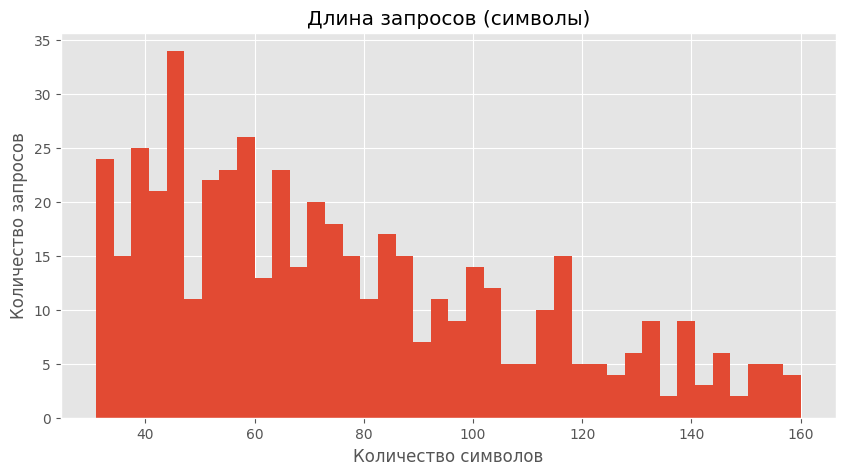

In [6]:
calibration["query_len"] = calibration["query_text"].str.len()
test["query_len"] = test["query_text"].str.len()

plt.figure(figsize=(10,5))
plt.hist(calibration["query_len"], bins=40)
plt.title("Длина запросов (символы)")
plt.xlabel("Количество символов")
plt.ylabel("Количество запросов")
plt.show()

Средняя длина статей: 5135.622950819672
Максимальная длина статьи: 506100
Медианная длина статей: 2240.0
Средняя длина заголовков: 29.21689785624212
Максимальная длина заголовка: 113


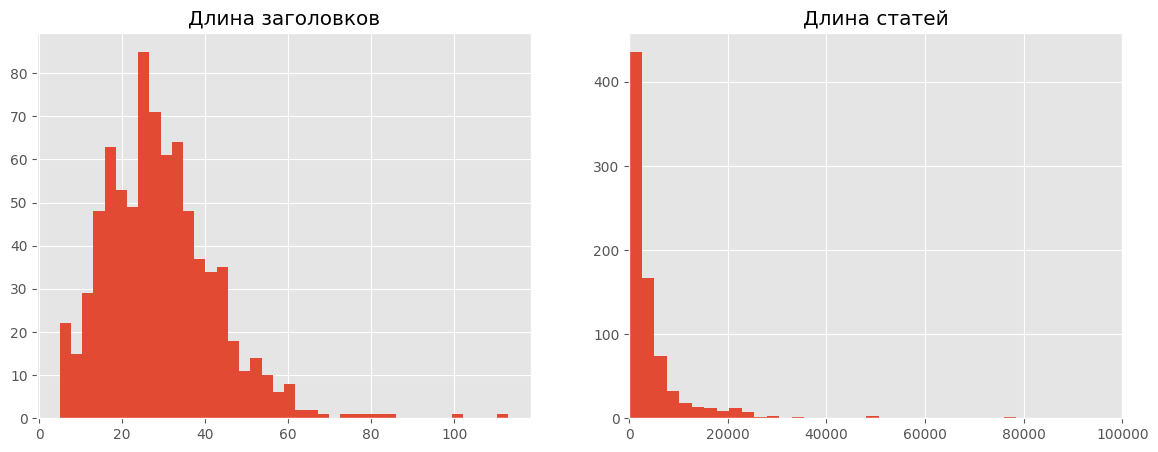

In [30]:
articles["title_len"] = articles["title"].str.len()
articles["body_len"] = articles["body_clean"].str.len()

print(f"Средняя длина статей: {articles['body_len'].mean()}")
print(f"Максимальная длина статьи: {articles['body_len'].max()}")
print(f"Медианная длина статей: {articles['body_len'].median()}")
print(f"Средняя длина заголовков: {articles['title_len'].mean()}")
print(f"Максимальная длина заголовка: {articles['title_len'].max()}")

fig, ax = plt.subplots(1,2, figsize=(14,5))

ax[0].hist(articles["title_len"], bins=40)
ax[0].set_title("Длина заголовков")

ax[1].hist(articles["body_len"], bins=200)
ax[1].set_title("Длина статей")
ax[1].set_xlim(0, 100000)

plt.show()

In [8]:
articles.sort_values("body_len", ascending=False)[
    ["article_id","title","body_len"]
].head(10)

,article_id,title,body_len
245,2924,Какими товарами интересуются покупатели,506100
730,4436,Уровень сервиса,77778
620,4321,Мой уровень сервиса,76279
527,4220,Объявление о транспорте,50589
572,4266,Недвижимость,50147
549,4243,"Вещи, техника и другие товары",49741
540,4234,Как продавать и покупать с доставкой,35123
548,4242,"Как указать параметры, чтобы объявления соедин...",29691
606,4307,Лимит бесплатных размещений,28076
563,4257,Как работать с Защитой сделки: информация для ...,28045


In [9]:
articles.sort_values("body_len")[
    ["article_id","title","body_len"]
].head(10)

,article_id,title,body_len
789,4547,Записаться на тест-драйв,24
303,3234,Изменение в поле «Сфера деятельности»,32
496,4170,Инструкции по ошибкам Автозагрузке,66
413,3785,Готовый бизнес и оборудование,87
274,3026,Списать бонусы за бронирование,93
417,3790,Сообщить о нарушении интеллектуальных прав,99
44,1889,Сообщить о нарушении интеллектуальных прав,99
117,2205,Скрыть объявление в профиле,103
264,2973,Видеоинструкция,124
497,4173,Инструкция по Автозагрузке,150


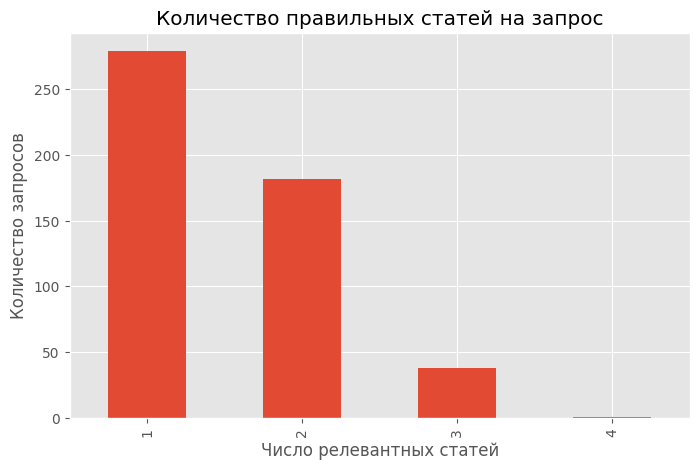

In [10]:
calibration["n_gt"] = calibration["ground_truth"].str.split().str.len()

plt.figure(figsize=(8,5))
calibration["n_gt"].value_counts().sort_index().plot(kind="bar")

plt.title("Количество правильных статей на запрос")
plt.xlabel("Число релевантных статей")
plt.ylabel("Количество запросов")

plt.show()

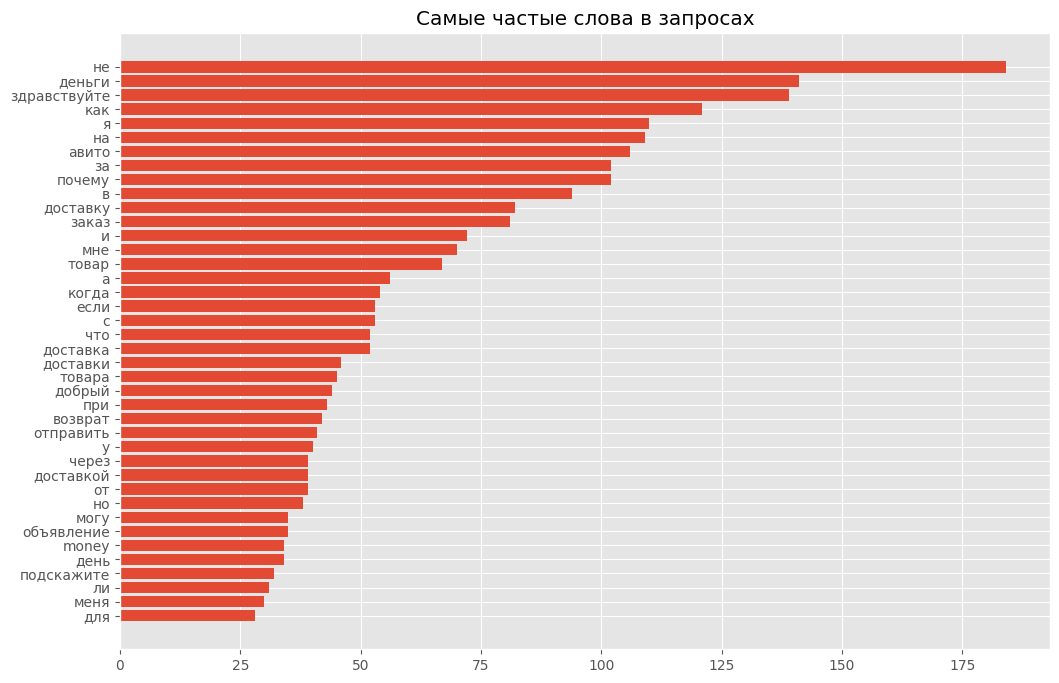

In [11]:
def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^а-яa-z0-9 ]", " ", text)
    return text.split()

counter = Counter()

for q in calibration.query_text:
    counter.update(tokenize(q))

common = counter.most_common(40)

words = [x[0] for x in common]
freq = [x[1] for x in common]

plt.figure(figsize=(12,8))
plt.barh(words[::-1], freq[::-1])
plt.title("Самые частые слова в запросах")
plt.show()

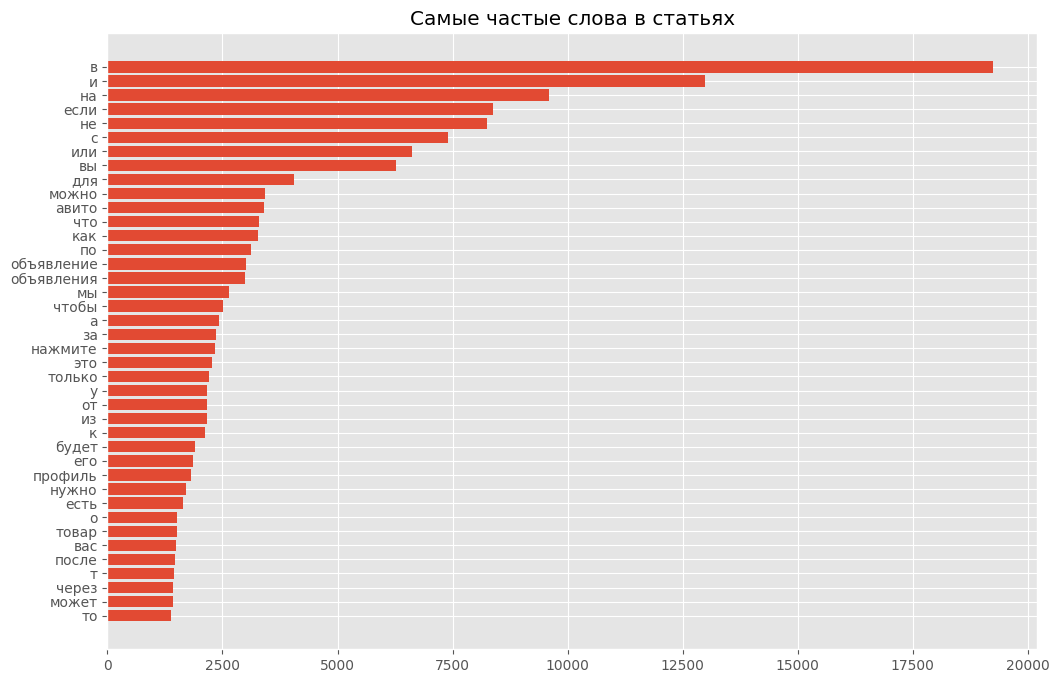

In [12]:
counter = Counter()

for text in articles.body_clean:
    counter.update(tokenize(text))

common = counter.most_common(40)

words = [x[0] for x in common]
freq = [x[1] for x in common]

plt.figure(figsize=(12,8))
plt.barh(words[::-1], freq[::-1])
plt.title("Самые частые слова в статьях")
plt.show()

In [13]:
morph = pymorphy2.MorphAnalyzer()

stop_words = set("""
        и в во не что он на я с со как а то все она так его но да ты к \
        у же вы за бы по только ее мне было вот от меня еще нет о из ему \
        теперь когда даже ну вдруг ли если уже или ни быть был него до вас \
        нибудь опять уж вам ведь там потом себя ничего ей может они тут где \
        есть надо ней для мы тебя их чем была сам чтоб без будто чего раз два
""".split())


def tokenize(text):
    text = text.lower()

    words = re.findall(r"[а-яё]+", text)
    result = []
    for w in words:
        if len(w) <= 2:
            continue
        
        if w in stop_words:
            continue
        
        lemma = morph.parse(w)[0].normal_form
        result.append(lemma)

    return result

In [14]:
from tqdm.auto import tqdm
tqdm.pandas()

articles["lemmas"] = articles["body_clean"].progress_apply(tokenize)

/home/p1xta/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 793/793 [00:30<00:00, 26.23it/s]


In [15]:
calibration["query_lemmas"] = calibration["query_text"].progress_apply(tokenize)
test["query_lemmas"] = test["query_text"].progress_apply(tokenize)

100%|██████████| 500/500 [00:00<00:00, 1578.45it/s]


100%|██████████| 793/793 [00:00<00:00, 25101.76it/s]


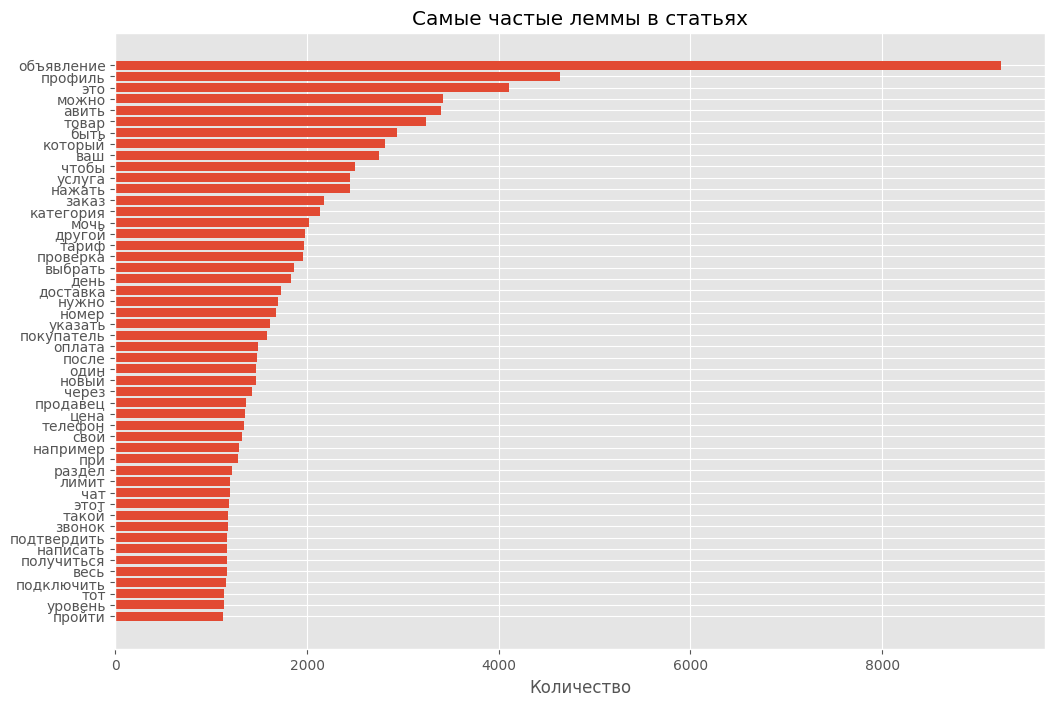

In [16]:
article_words = Counter()

for words in tqdm(articles["lemmas"]):
    article_words.update(words)

top_articles_words = article_words.most_common(50)
words = [x[0] for x in top_articles_words]
count = [x[1] for x in top_articles_words]

plt.figure(figsize=(12,8))

plt.barh(words[::-1], count[::-1])
plt.title("Самые частые леммы в статьях")

plt.xlabel("Количество")
plt.show()

100%|██████████| 500/500 [00:00<00:00, 405246.76it/s]


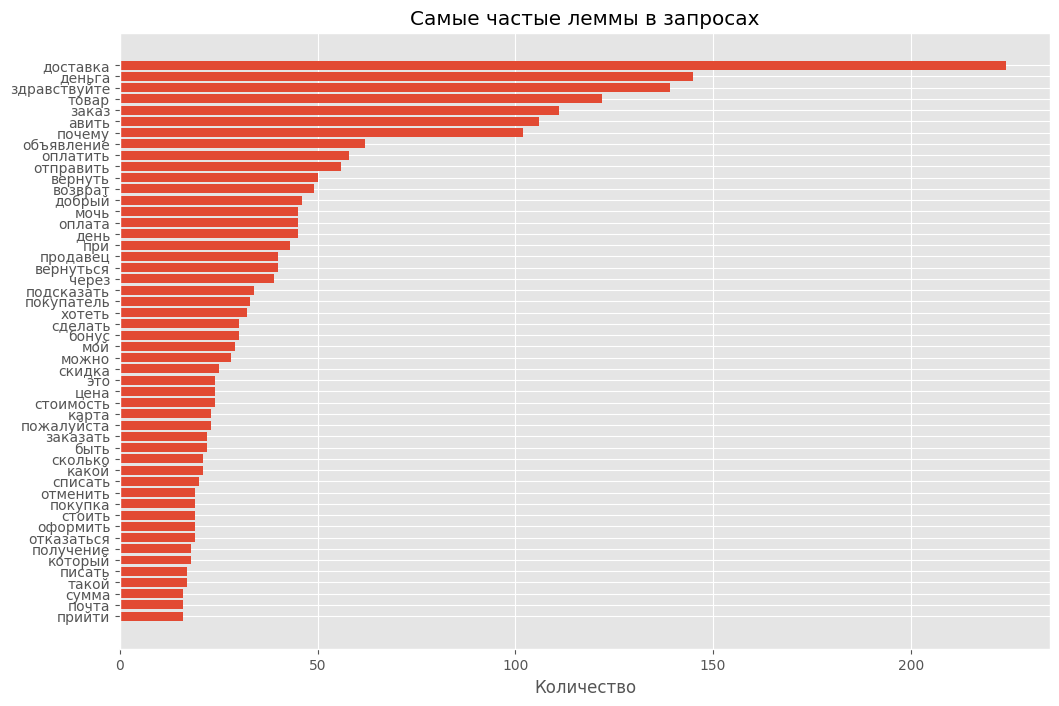

In [17]:
query_words = Counter()

for words in tqdm(calibration["query_lemmas"]):
    query_words.update(words)


top_query_words = query_words.most_common(50)
words = [x[0] for x in top_query_words]
count = [x[1] for x in top_query_words]

plt.figure(figsize=(12,8))

plt.barh(words[::-1], count[::-1])
plt.title("Самые частые леммы в запросах")

plt.xlabel("Количество")
plt.show()

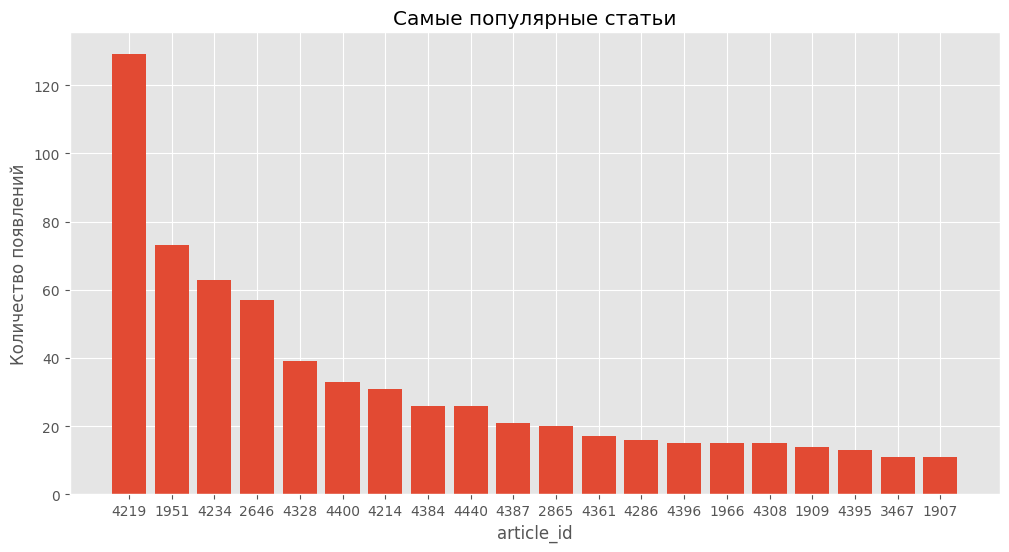

In [18]:
counter = Counter()

for ids in calibration.ground_truth:
    counter.update(ids.split())

top = counter.most_common(20)

df = pd.DataFrame(top, columns=["article_id","count"])

plt.figure(figsize=(12,6))
plt.bar(df.article_id.astype(str), df["count"])

plt.title("Самые популярные статьи")
plt.xlabel("article_id")
plt.ylabel("Количество появлений")

plt.show()

In [19]:
def show_article(article_id):
    row = articles.loc[articles.article_id == article_id].iloc[0]

    print(row.title)
    print(row.body_clean[:5000])

In [20]:
for idx, c in top[:5]:
    show_article(int(idx))
    print()

Покупателю
Оплатить заказ при получении 🔔 Не все пользователи могут оплатить заказ при получении — пока мы только тестируем эту функцию. Некоторые заказы в пункты выдачи Авито и Почты России можно оплатить при получении. Ещё это можно сделать при самовывозе с онлайн-оплатой. Когда будете оформлять заказ, выберите способ оплаты При получении . Такой заказ нельзя оплатить кошельком Авито. Если такого способа нет — заказ нужно оплатить сразу или (некоторые товары можно купить в рассрочку). Заказали в пункт Авито или Почты России: В таком заказе может быть только один товар , даже если покупаете через корзину. У покупателя может быть не больше 3 активных заказов с оплатой при получении, а у продавца — не больше 5. Ещё дополнительные условия есть у каждой службы доставки. Авито Почта России Самовывоз с онлайн-оплатой Как заказать Не все товары можно оплатить при получении. Если эта форма оплаты доступна, то при оформлении покупки выберите: Способ оплаты → При получении Далее укажите, как хо

In [34]:
show_article(1951)

Кто оплачивает доставку и сколько она стоит
Обычно доставку полностью оплачивает покупатель. Но для заказов в пункт выдачи или постамат некоторые продавцы могут сделать скидку на доставку . Такие объявления можно заметить по значку: Стоимость доставки формируется автоматически и зависит от категории товара, цены, расстояния, а для грузовой доставки — ещё от веса и габаритов. Финальная цена доставки появится при оформлении заказа. Если доставка силами продавца Когда продавец сам организует доставку , стоимость и сроки будут зависеть от условий договора со службой доставки. Для продавца комиссия за сделку с доставкой составит от 1 рубля. Если в объявлении не написано, сколько стоит доставка, покупатель может нажать Запросить стоимость доставки или Продолжить , когда будет оформлять заказ. Продавец укажет всю информацию, а мы передадим её покупателю. Если всё подойдёт, он сможет оформить и оплатить заказ. Если самовывоз с онлайн-оплатой Для продавца комиссия за сделку составит от 1 рубля.